<a href="https://colab.research.google.com/github/jiissung/ML_Prediction/blob/main/Model_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [219]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Given a job's description, can we predict its given salary

**This is a prediction (umbrella) problem because:** We are finding if we can predict salary from job descriptions
(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** This decision enables people who are currently finding jobs. They would have an estimated salary from job descriptions and would make choices based on the estimate.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** Data Science, AI & ML Job Salaries in 2025
- **Source:** Kaggle (URL: https://www.kaggle.com/datasets/adilshamim8/salaries-for-data-science-jobs)
- **N =** 151446
- **Features =** 11
- **Target variable =** Salary
- **Access date:** 4/20/2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [220]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
# Replace the URL/path below with your data source

df = pd.read_csv('cancer-risk-factors.csv')

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (2000, 21)
Columns: ['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use', 'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed', 'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution', 'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection', 'Calcium_Intake', 'Overall_Risk_Score', 'BMI', 'Physical_Activity_Level', 'Risk_Level']


,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


### 2.2 Basic Description

In [221]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   str    
 1   Cancer_Type              2000 non-null   str    
 2   Age                      2000 non-null   int64  
 3   Gender                   2000 non-null   int64  
 4   Smoking                  2000 non-null   int64  
 5   Alcohol_Use              2000 non-null   int64  
 6   Obesity                  2000 non-null   int64  
 7   Family_History           2000 non-null   int64  
 8   Diet_Red_Meat            2000 non-null   int64  
 9   Diet_Salted_Processed    2000 non-null   int64  
 10  Fruit_Veg_Intake         2000 non-null   int64  
 11  Physical_Activity        2000 non-null   int64  
 12  Air_Pollution            2000 non-null   int64  
 13  Occupational_Hazards     2000 non-null   int64  
 14  BRCA_Mutation            2000 non-n

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.000000,2000.000000
mean,63.248000,0.489000,5.157000,5.035000,5.967500,0.194500,5.189500,4.563500,4.927500,4.015000,5.323000,4.979000,0.032500,0.19650,3.94050,0.454449,26.183350,4.938500
std,10.462946,0.500004,3.325339,3.260996,3.061393,0.395914,3.154452,3.088323,3.045305,2.978458,3.207462,3.212899,0.177368,0.39745,3.04887,0.123074,3.947459,3.166027
min,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.029285,15.000000,0.000000
25%,56.000000,0.000000,2.000000,2.000000,4.000000,0.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,0.000000,0.00000,1.00000,0.366982,23.500000,2.000000
50%,64.000000,0.000000,5.000000,5.000000,6.000000,0.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,0.000000,0.00000,4.00000,0.455399,26.200000,5.000000
75%,70.000000,1.000000,8.000000,8.000000,9.000000,0.000000,8.000000,7.000000,8.000000,6.000000,8.000000,8.000000,0.000000,0.00000,6.00000,0.539782,28.700000,8.000000
max,90.000000,1.000000,10.000000,10.000000,10.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.00000,10.00000,0.852158,41.400000,10.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


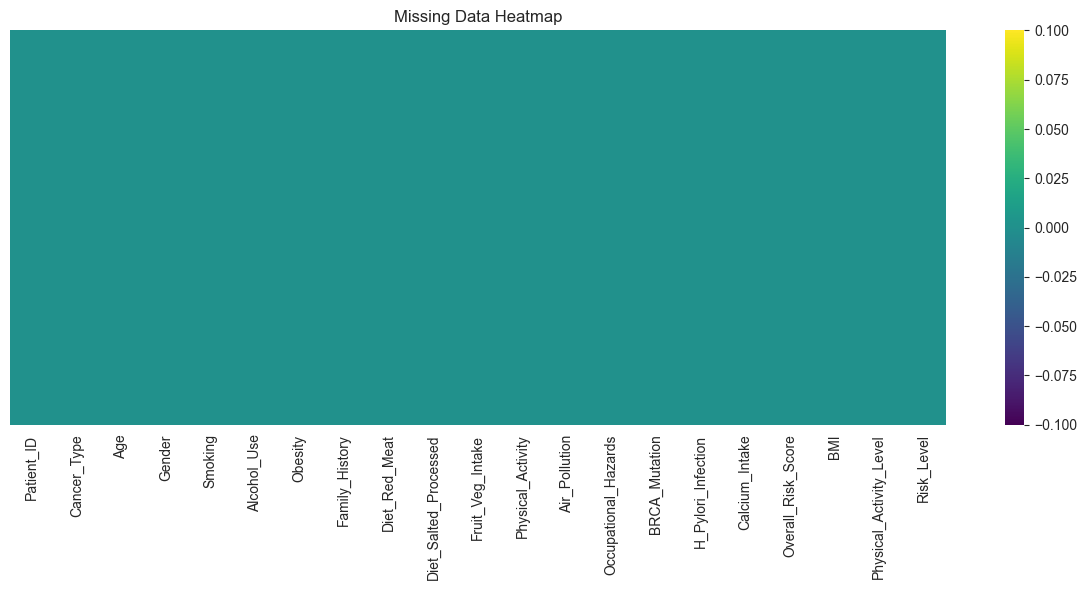

In [222]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** ___
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

### 2.4 Distribution Plots

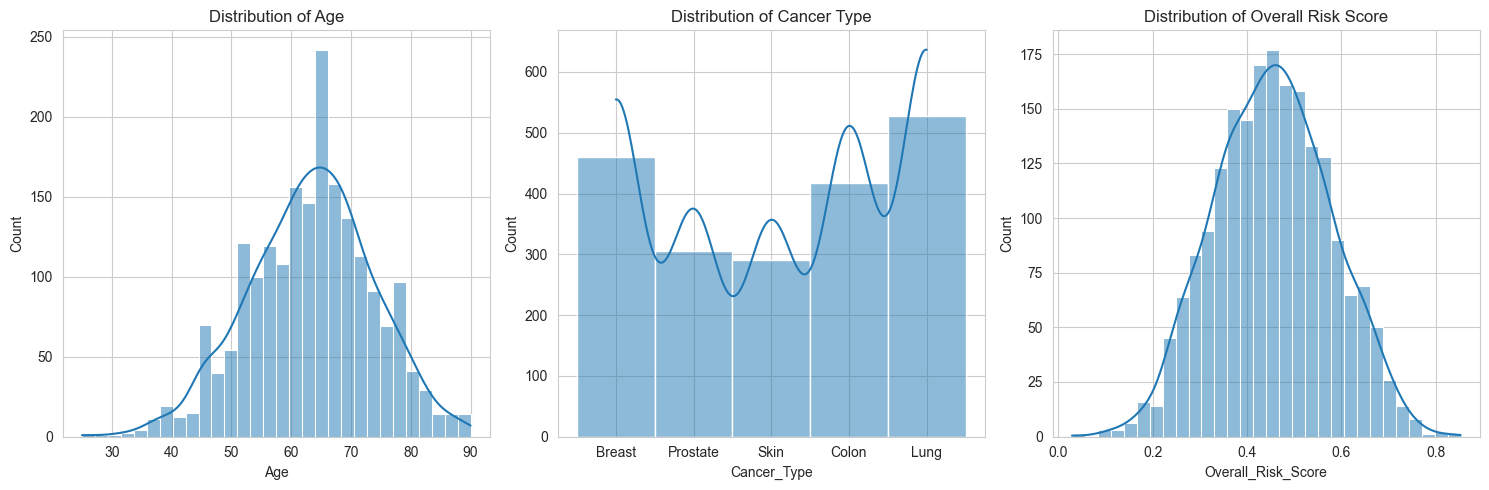

In [223]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(df["Cancer_Type"], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Cancer Type')

sns.histplot(df['Overall_Risk_Score'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Overall Risk Score')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [224]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

# Example: check outliers in a numeric column
cols = ['Age', 'BMI', 'Overall_Risk_Score']

for col in cols:
  lower, upper = tukey_fences(df[col])
  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')



Age: 9 outliers (0.4%)
BMI: 17 outliers (0.9%)
Overall_Risk_Score: 6 outliers (0.3%)


**Outlier strategy:** The project will trim the outliers. They are a very small percetnage of the total amount of observations. Removing them will improve model stability for the small cost of losing 32 total observations out of 2000.
(Trim? Winsorize? Keep with justification?)

In [225]:
cols = ['Age', 'BMI', 'Overall_Risk_Score']

mask = pd.Series(True, index=df.index)

for col in cols:
    lower, upper = tukey_fences(df[col])
    mask &= (df[col] >= lower) & (df[col] <= upper)

df = df[mask]

print(f"Original size: {len(df)}")
print(f"Cleaned size: {len(df)}")

Original size: 1968
Cleaned size: 1968


### 2.6 Correlations

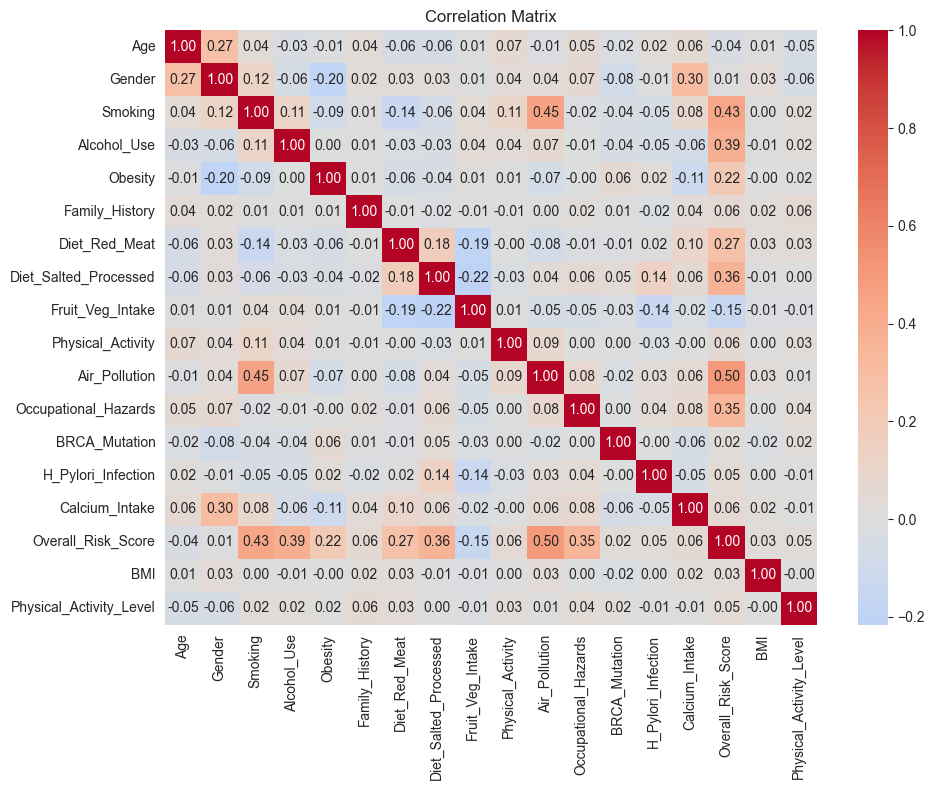

In [226]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The distribution of my target variable is normally distributed

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* The features most  correlated with Overall_Risk_Score are Air_Pollution, Smoking, Alcohol_Use, Diet_Salted_Processed, Obesity, and Diet_Red_Meat.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The main data quality issue is the presence of outliers. The number of outliers is small, therefore I will trim solve this issue by trimming the dataset.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 2000** observations and **M = 18** features.

**Missing data:** 0% of cells are missing. There is no need to deal with missing data

**Outliers:** I identified 32 outliers using Tukey Fences. I will handle them by trimming.

**Target variable:** The target variable (Overall_risk_Score) is normally distributed. It is suitable for regression modeling.

**Key finding from EDA:** Air_Pollution, Smoking, Alcohol_Use, Diet_Salted_Processed, Obesity, and Diet_Red_Meat show postiive correlations with the target feature. They may be important predictors of risk.

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [227]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

from sklearn.preprocessing import StandardScaler

# Define features and target
X = df[['Air_Pollution', 'Smoking', 'Alcohol_Use', 'Diet_Salted_Processed', 'Obesity', 'Diet_Red_Meat', 'Age', 'BMI', 'Family_History', 'Fruit_Veg_Intake', 'Physical_Activity_Level', 'BRCA_Mutation']]
y = df['Overall_Risk_Score']  # Replace with your target

# For classification: use stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# For regression: remove stratify
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 


Train: 1574 samples
Test:  394 samples


### Model 1: Linear Regression

In [228]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge  # or LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor 
from xgboost import XGBRegressor

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print('Model 1: Linear Regression')

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression
RMSE: 0.0633
MAE:  0.0499
R2:   0.7234


### Model 2: Ridge Regression

In [229]:
ridge_alphas = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
ridge_scores = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
    ridge_scores.append(scores.mean())

best_alpha = ridge_alphas[np.argmax(ridge_scores)]
print(f"Best alpha: {best_alpha}")

ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train, y_train)

# Best Parameters
y_pred_2 = ridge_best.predict(X_test)

print('\nModel 2: Random Forest')

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Best alpha: 5.0

Model 2: Random Forest
RMSE: 0.0633
MAE:  0.0499
R2:   0.7234


### Model 3: Random Forest Regressor

In [230]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=RANDOM_STATE)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='r2', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

# Best Parameters
model_3_best = grid_search.best_estimator_

y_pred_3 = model_3_best.predict(X_test)

print('\nModel 3: Random Forest')

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_3)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_3):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_3):.4f}')

Fitting 5 folds for each of 81 candidates, totalling 405 fits

Model 3: Random Forest
RMSE: 0.0712
MAE:  0.0560
R2:   0.6508


### Model 4: Gradient Boosted  Regressor


In [231]:
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_base = GradientBoostingRegressor(random_state=42)
gb_search = GridSearchCV(
    gb_base, gb_param_grid, cv=5, scoring='r2', 
    n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)

print(f"\nBest Parameters: {gb_search.best_params_}")
print(f"Best CV R²: {gb_search.best_score_:.4f}")

# Best Parameters
gb_best = gb_search.best_estimator_

y_pred_4 = gb_best.predict(X_test)

print('\nModel 4: Gradient Boosted ')

print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_4)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_4):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_4):.4f}')


Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV R²: 0.6412

Model 4: Gradient Boosted 
RMSE: 0.0720
MAE:  0.0572
R2:   0.6425


### Model 5: XG Boost 

In [232]:
param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [3, 5, 7],              
    'learning_rate': [0.01, 0.05, 0.1],  
    'subsample': [0.8, 0.9, 1.0],        
    'colsample_bytree': [0.8, 0.9, 1.0],  
    'min_child_weight': [1, 3, 5]       
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

xgb_grid_search = GridSearchCV(
    xgb_base, 
    param_grid, 
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

# Best Parameters
xgb_best = xgb_grid_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)

print('Model 4: Gradient Boosted ')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_xgb):.4f}')

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Model 4: Gradient Boosted 
RMSE: 0.0668
MAE:  0.0524
R2:   0.6928


### 3.4 Cross-Validation Comparison

In [233]:
scoring = 'r2'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(ridge_best, X_train, y_train, cv=5, scoring=scoring)
cv_3 = cross_val_score(model_3_best, X_train, y_train, cv = 5, scoring = scoring)
cv_4 = cross_val_score(gb_best, X_train, y_train, cv = 5, scoring = scoring)
cv_5 = cross_val_score(xgb_best, X_train, y_train, cv = 5, scoring = scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
print(f'Model 3 CV {scoring}: {cv_3.mean():.4f} +/- {cv_3.std():.4f}')
print(f'Model 4 CV {scoring}: {cv_4.mean():.4f} +/- {cv_4.std():.4f}')
print(f'Model 5 CV {scoring}: {cv_5.mean():.4f} +/- {cv_5.std():.4f}')

# Comparison table
comparison = pd.DataFrame({
    'Model': ['Model 1 (Linear Regression)', 'Model 2 (Ridge Regression)', "Model 3 (Random Forest Regressor)", "Model 4 (Gradient Boosted Regressor)", "Model 5 (XGB Regressor)"],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean(), cv_3.mean(), cv_4.mean(), cv_5.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std(), cv_3.std(), cv_4.std(), cv_5.std()],
})
comparison

Model 1 CV r2: 0.7298 +/- 0.0201
Model 2 CV r2: 0.7298 +/- 0.0201
Model 3 CV r2: 0.6613 +/- 0.0190
Model 4 CV r2: 0.6412 +/- 0.0297
Model 5 CV r2: 0.7006 +/- 0.0247


,Model,CV r2 (mean),CV r2 (std)
0,Model 1 (Linear Regression),0.729811,0.020066
1,Model 2 (Ridge Regression),0.729830,0.020078
2,Model 3 (Random Forest Regressor),0.661283,0.019045
3,Model 4 (Gradient Boosted Regressor),0.641204,0.029699
4,Model 5 (XGB Regressor),0.700637,0.024682


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

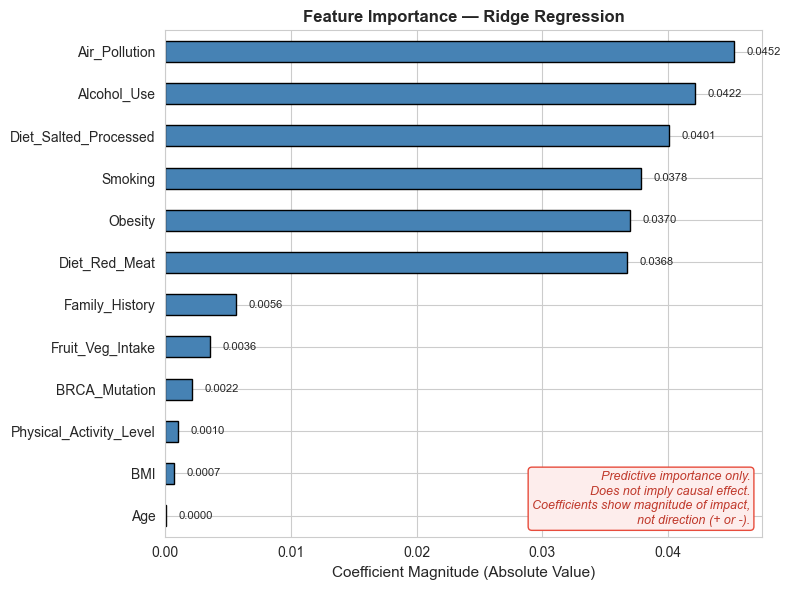

In [234]:
# ============================================================
# 4.1 Feature Importance for Ridge Regression
# ============================================================

# Get coefficients from Ridge model (trained on scaled data)
coefficients = pd.Series(
    abs(ridge_best.coef_), 
    index=X.columns 
).sort_values(ascending=True)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
coefficients.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Coefficient Magnitude (Absolute Value)', fontsize=11)
ax.set_title('Feature Importance — Ridge Regression', 
             fontsize=12, fontweight='bold')

# Value Labels
for i, (idx, value) in enumerate(coefficients.items()):
    ax.text(value + 0.001, i, f'{value:.4f}', va='center', fontsize=8)

# Add the caveat banner
ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.\nCoefficients show magnitude of impact,\nnot direction (+ or -).',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

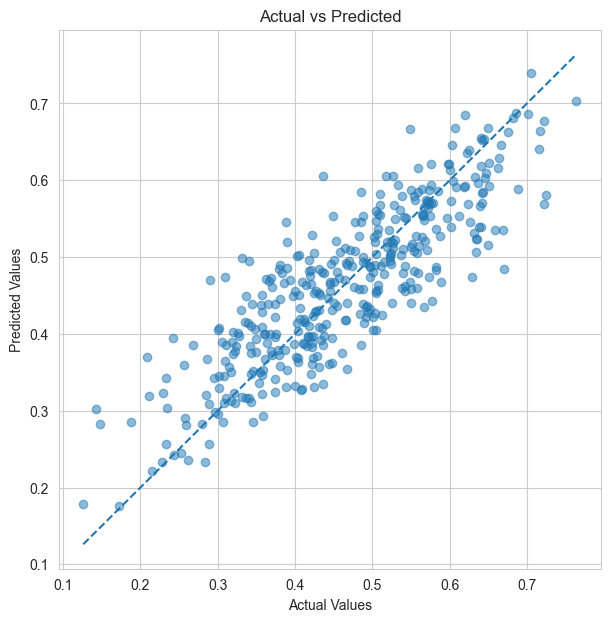

In [235]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature


plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_2, alpha=0.5)

min_val = min(y_test.min(), y_pred_2.min())
max_val = max(y_test.max(), y_pred_2.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.grid(True)

plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** A stakeholder in this analysis is any member of public health who wants to  have a better understanding of  the facotrs that most influence an individual's Overall Risk Score of cancer. The goal is to use this analysis to drive prevention strategies.

**Complication:** The relationship between risk factors and risk score is extremely complex with multiple interacting variables. While the dataset was clean, requiring little pre-processing, uncertainty can still be present due to correlations between predictors and outliers. Our analysis revealed that while the chosen factors are related to risk levels, there are still more factors that influence cancer risk.

**Resolution:** I recommend using the Ridge Regression as the primary model. It best captures linear relationships and interactions more effectively than other models. The Ridge Regression has the greatest CV R^2 value, therefore is the best model. Although, the Linear Regression model is almost identical to the Ridge model. 

**Uncertainty Statement:** Based on our cross-validation results (metric = 0.729830 ± 0.020078), we estimate that the model explains a substantial portion of the variance in the risk score. The primary limitation is may not fully capture unobserved variables or causal relationships. We recommend using these results as guidance rather than evidence supporting a decision.

In [239]:
joblib.dump(ridge_best, 'model.pkl')

['model.pkl']

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___